# EfficientNet-B0 image model

Binary image classification using the preprocessed **136×136 lesion images** directly.

Current hypotheses:
- H1: biopsy recommendation
- H2: malignancy among biopsied lesions

Model development is performed exclusively within the selected training split:

1. one patient-grouped, approximately stratified internal holdout is created from the training data;
2. EfficientNet-B0 is trained with class-weighted binary cross-entropy;
3. early stopping uses the same metric hierarchy as the XGBoost workflow: **PR-AUC → ROC-AUC → Brier score**;
4. the selected training duration is used to refit a fresh model on the complete selected training split;
5. only then is the external validation set evaluated with the common `evaluation.py` pipeline.

The external test set is loaded only as metadata and remains untouched.

## 1. Imports and configuration

In [60]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------

import copy
import json
import random
import re
from datetime import datetime
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    auc,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    efficientnet_b0,
)
from tqdm.auto import tqdm

from skin_lesion_ai.inference.evaluation import (
    evaluate,
    save_model,
)
from skin_lesion_ai.utils.data_utils import (
    load_metadata_parquet,
    load_yaml_config,
    path,
    subsample_training_split,
)


# ---------------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 2

IMAGE_SIZE = 136
IMAGE_TIMESTAMP = None  # None -> latest matching preprocessing manifest

# Reproducible training-size control.
# None -> use the complete training split.
# Example: 3000 -> retain complete patients up to approximately 3000 lesions.
TRAIN_MAX_LESIONS = None

RANDOM_STATE = 42
TRAIN_SUBSAMPLE_RANDOM_STATE = 42

# Internal model-development holdout.
# A single fold is used, not full cross-validation.
N_INTERNAL_FOLDS = 5
INTERNAL_FOLD_INDEX = 0

# Training configuration.
BATCH_SIZE = 32
NUM_WORKERS = 4 if torch.cuda.is_available() else 0
IO_BATCH_SIZE = 4096

WARMUP_EPOCHS = 2
MAX_FINE_TUNE_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3

WARMUP_LR = 1e-3
FINE_TUNE_LR = 5e-5
WEIGHT_DECAY = 1e-4

# Fine-tune only the last EfficientNet feature blocks.
UNFREEZE_LAST_N_BLOCKS = 4

# Options: "none", "sqrt", "full".
POS_WEIGHT_MODE = "full"

DROPOUT = 0.4

MODEL_ARCHITECTURE = "efficientnet_b0"
WEIGHTS = EfficientNet_B0_Weights.DEFAULT

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


# ---------------------------------------------------------------------
# Hypothesis configuration
# ---------------------------------------------------------------------

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_suffix": "h1",
        "description": "Biopsy recommendation",
    },
    2: {
        "target": "target_malignant",
        "split_suffix": "h2",
        "description": "Malignancy among biopsied lesions",
    },
}

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

if INTERNAL_FOLD_INDEX not in range(N_INTERNAL_FOLDS):
    raise ValueError("INTERNAL_FOLD_INDEX must identify one valid internal fold.")

if POS_WEIGHT_MODE not in {"none", "sqrt", "full"}:
    raise ValueError("POS_WEIGHT_MODE must be 'none', 'sqrt' or 'full'.")

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_SUFFIX = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_suffix"]
HYPOTHESIS_DESCRIPTION = HYPOTHESIS_CONFIG[HYPOTHESIS]["description"]

TRAIN_SIZE_TAG = "full_train" if TRAIN_MAX_LESIONS is None else f"n{TRAIN_MAX_LESIONS}"

MODEL_NAME = f"efficientnet_b0_image_h{HYPOTHESIS}_{TRAIN_SIZE_TAG}"


# ---------------------------------------------------------------------
# Device and reproducibility
# ---------------------------------------------------------------------


def select_device() -> torch.device:
    """Select CUDA, Apple MPS or CPU."""

    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


def set_seed(seed: int) -> None:
    """Set the principal random seeds used by this notebook."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)
DEVICE = select_device()
PIN_MEMORY = DEVICE.type == "cuda"
USE_AMP = DEVICE.type == "cuda"

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

print(f"Hypothesis {HYPOTHESIS}: {HYPOTHESIS_DESCRIPTION}")
print(f"Target: {TARGET}")
print(f"Model: {MODEL_ARCHITECTURE}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Training size setting: {TRAIN_SIZE_TAG}")
print(f"Device: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")
print(f"Model name: {MODEL_NAME}")

Hypothesis 2: Malignancy among biopsied lesions
Target: target_malignant
Model: efficientnet_b0
Image size: 136x136
Training size setting: full_train
Device: cpu
Mixed precision: False
Model name: efficientnet_b0_image_h2_full_train


## 2. Load train, validation and test metadata

The original H1/H2 patient-independent splits are reused unchanged.

If `TRAIN_MAX_LESIONS` is set, only the training split is reduced. Validation and test remain complete.

In [61]:
df_train_full = load_metadata_parquet(
    stage="processed",
    filename=f"train_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_validation = load_metadata_parquet(
    stage="processed",
    filename=f"val_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_test = load_metadata_parquet(
    stage="processed",
    filename=f"test_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)


df_train = subsample_training_split(
    df=df_train_full,
    n_samples=TRAIN_MAX_LESIONS,
    target_column=TARGET,
    id_column="isic_id",
    random_state=TRAIN_SUBSAMPLE_RANDOM_STATE,
)


for dataframe in (
    df_train_full,
    df_train,
    df_validation,
    df_test,
):
    dataframe["isic_id"] = dataframe["isic_id"].astype(str)
    dataframe["patient_id"] = dataframe["patient_id"].astype(str)


split_summary = pd.DataFrame(
    {
        "split": [
            "train_full",
            "train_used",
            "validation",
            "test",
        ],
        "lesions": [
            len(df_train_full),
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "patients": [
            df_train_full["patient_id"].nunique(),
            df_train["patient_id"].nunique(),
            df_validation["patient_id"].nunique(),
            df_test["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train_full[TARGET].mean(),
            df_train[TARGET].mean(),
            df_validation[TARGET].mean(),
            df_test[TARGET].mean(),
        ],
    }
)

display(split_summary)

,split,lesions,patients,positive_rate
0,train_full,811,504,0.374846
1,train_used,811,504,0.374846
2,validation,101,64,0.376238
3,test,101,61,0.376238


## 3. Resolve and load the preprocessed image bytes

The project stores the 136×136 RGB lesion images as JPEG bytes inside Parquet shards.

Only lesions required for the selected training split and the external validation split are retained in memory. The Parquet collection is scanned once.

The test images are deliberately not loaded.

In [62]:
CONFIG_PATH = "configs/data_config.yaml"
INPUT_BASENAME = "raw_images_preprocessed"


def resolve_image_run(
    image_size: int,
    timestamp_value: str | None = None,
) -> tuple[Path, list[Path], dict]:
    """Resolve one preprocessed-image manifest and its Parquet files."""

    config = load_yaml_config(path(CONFIG_PATH))
    image_dir = path(config["paths"]["interim"]["images"])

    if not image_dir.exists():
        raise FileNotFoundError(f"Interim image directory not found: {image_dir}")

    prefix = f"{INPUT_BASENAME}_{image_size}"

    if timestamp_value is not None:
        try:
            datetime.strptime(timestamp_value, "%Y%m%d_%H%M%S")
        except ValueError as exc:
            raise ValueError("IMAGE_TIMESTAMP must use YYYYmmdd_HHMMSS.") from exc

        manifest_path = image_dir / f"{prefix}_{timestamp_value}_manifest.json"

        if not manifest_path.exists():
            raise FileNotFoundError(f"Image manifest not found: {manifest_path}")

    else:
        pattern = re.compile(rf"^{re.escape(prefix)}_(\d{{8}}_\d{{6}})_manifest\.json$")

        candidates = []

        for candidate in image_dir.glob(f"{prefix}_*_manifest.json"):
            match = pattern.match(candidate.name)

            if not match:
                continue

            try:
                parsed_timestamp = datetime.strptime(
                    match.group(1),
                    "%Y%m%d_%H%M%S",
                )
            except ValueError:
                continue

            candidates.append((parsed_timestamp, candidate))

        if not candidates:
            raise FileNotFoundError(
                f"No preprocessing manifest found for {image_size}x{image_size} images."
            )

        manifest_path = max(
            candidates,
            key=lambda item: item[0],
        )[1]

    with manifest_path.open("r", encoding="utf-8") as file:
        manifest = json.load(file)

    required_keys = {"image_size", "n_rows", "files"}
    missing_keys = required_keys.difference(manifest)

    if missing_keys:
        raise ValueError(f"Image manifest is missing keys: {sorted(missing_keys)}")

    if int(manifest["image_size"]) != image_size:
        raise ValueError(
            f"Manifest image size ({manifest['image_size']}) does not match "
            f"IMAGE_SIZE ({image_size})."
        )

    parquet_paths = []

    for file_value in manifest["files"]:
        candidate = Path(file_value)

        if candidate.exists():
            parquet_paths.append(candidate)
            continue

        fallback = image_dir / candidate.name

        if fallback.exists():
            parquet_paths.append(fallback)
            continue

        raise FileNotFoundError(
            f"Parquet file listed in the manifest was not found: {file_value}"
        )

    if not parquet_paths:
        raise FileNotFoundError("No image Parquet files were resolved.")

    return manifest_path, parquet_paths, manifest


def load_selected_image_bytes(
    parquet_paths: list[Path],
    lesion_ids,
    io_batch_size: int,
) -> pd.DataFrame:
    """Load only requested lesion images from the Parquet collection."""

    requested_ids = {str(lesion_id) for lesion_id in lesion_ids}

    if not requested_ids:
        raise ValueError("No lesion identifiers were requested.")

    required_columns = ["lesion_id", "patient_id", "image"]
    chunks = []

    for parquet_path in tqdm(
        parquet_paths,
        desc="Scanning image shards",
    ):
        parquet_file = pq.ParquetFile(parquet_path)

        available_columns = set(parquet_file.schema.names)
        missing_columns = set(required_columns).difference(available_columns)

        if missing_columns:
            raise ValueError(
                f"{parquet_path.name} is missing columns: {sorted(missing_columns)}"
            )

        for record_batch in parquet_file.iter_batches(
            batch_size=io_batch_size,
            columns=required_columns,
        ):
            batch_df = record_batch.to_pandas()
            batch_ids = batch_df["lesion_id"].astype(str)
            mask = batch_ids.isin(requested_ids)

            if not mask.any():
                continue

            selected = batch_df.loc[mask, required_columns].copy()
            selected["lesion_id"] = selected["lesion_id"].astype(str)
            selected["patient_id"] = selected["patient_id"].astype(str)
            chunks.append(selected)

    if not chunks:
        raise ValueError(
            "None of the requested lesions were found in the image Parquet files."
        )

    image_df = pd.concat(chunks, ignore_index=True)

    if image_df["lesion_id"].duplicated().any():
        raise ValueError("Duplicated lesion_id values found in the loaded images.")

    loaded_ids = set(image_df["lesion_id"])
    missing_ids = requested_ids.difference(loaded_ids)

    if missing_ids:
        examples = sorted(missing_ids)[:10]

        raise ValueError(
            f"{len(missing_ids):,} requested lesions were not found. "
            f"Examples: {examples}"
        )

    return image_df


image_manifest_path, image_parquet_paths, image_manifest = resolve_image_run(
    image_size=IMAGE_SIZE,
    timestamp_value=IMAGE_TIMESTAMP,
)

required_image_ids = set(df_train["isic_id"]).union(set(df_validation["isic_id"]))

df_images = load_selected_image_bytes(
    parquet_paths=image_parquet_paths,
    lesion_ids=required_image_ids,
    io_batch_size=IO_BATCH_SIZE,
)

print(f"Image manifest: {image_manifest_path}")
print(f"Parquet shards: {len(image_parquet_paths)}")
print(f"Images retained: {len(df_images):,}")

Scanning image shards:   0%|          | 0/1 [00:00<?, ?it/s]

Image manifest: /Users/carlesraichbros/my-image-classifier/data/interim/images/raw_images_preprocessed_136_20260621_082715_manifest.json
Parquet shards: 1
Images retained: 912


## 4. Validate and align metadata with images

In [63]:
ID_COLUMN = "isic_id"
IMAGE_ID_COLUMN = "lesion_id"
GROUP_COLUMN = "patient_id"


def merge_metadata_and_images(
    metadata_df: pd.DataFrame,
    image_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    """Align one metadata split with its JPEG bytes."""

    required_metadata_columns = {
        ID_COLUMN,
        GROUP_COLUMN,
        TARGET,
    }

    missing_metadata = required_metadata_columns.difference(metadata_df.columns)

    if missing_metadata:
        raise KeyError(
            f"{split_name} metadata are missing columns: {sorted(missing_metadata)}"
        )

    metadata = metadata_df.copy()
    images = image_df.copy()

    metadata[ID_COLUMN] = metadata[ID_COLUMN].astype(str)
    metadata[GROUP_COLUMN] = metadata[GROUP_COLUMN].astype(str)
    images[IMAGE_ID_COLUMN] = images[IMAGE_ID_COLUMN].astype(str)
    images[GROUP_COLUMN] = images[GROUP_COLUMN].astype(str)

    selected_images = images.loc[
        images[IMAGE_ID_COLUMN].isin(set(metadata[ID_COLUMN]))
    ].copy()

    if len(selected_images) != len(metadata):
        raise ValueError(
            f"{split_name} metadata/image row-count mismatch: "
            f"{len(metadata):,} metadata rows versus "
            f"{len(selected_images):,} image rows."
        )

    patient_check = metadata[[ID_COLUMN, GROUP_COLUMN]].merge(
        selected_images[[IMAGE_ID_COLUMN, GROUP_COLUMN]],
        left_on=ID_COLUMN,
        right_on=IMAGE_ID_COLUMN,
        how="inner",
        validate="one_to_one",
        suffixes=("_metadata", "_image"),
    )

    mismatch_mask = (
        patient_check[f"{GROUP_COLUMN}_metadata"]
        != patient_check[f"{GROUP_COLUMN}_image"]
    )

    if mismatch_mask.any():
        raise ValueError(f"Patient-ID mismatch detected in {split_name}.")

    image_table = selected_images[[IMAGE_ID_COLUMN, "image"]].copy()

    merged = metadata.merge(
        image_table,
        left_on=ID_COLUMN,
        right_on=IMAGE_ID_COLUMN,
        how="left",
        validate="one_to_one",
    ).drop(columns=IMAGE_ID_COLUMN)

    if merged["image"].isna().any():
        raise ValueError(f"Missing image bytes found in {split_name}.")

    return merged


df_train_images = merge_metadata_and_images(
    metadata_df=df_train,
    image_df=df_images,
    split_name="train",
)

df_validation_images = merge_metadata_and_images(
    metadata_df=df_validation,
    image_df=df_images,
    split_name="validation",
)

print(f"Training images aligned: {len(df_train_images):,}")
print(f"Validation images aligned: {len(df_validation_images):,}")

Training images aligned: 811
Validation images aligned: 101


## 5. Create the internal training holdout

Full neural-network cross-validation would multiply the training cost substantially.

Instead, one fold from a 5-fold `StratifiedGroupKFold` partition is used as an **internal validation holdout**. This gives an approximately 80/20 development split while keeping all lesions from each patient together.

The external validation set is not used at this stage.

In [64]:
internal_splitter = StratifiedGroupKFold(
    n_splits=N_INTERNAL_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

internal_splits = list(
    internal_splitter.split(
        X=np.zeros(len(df_train_images)),
        y=df_train_images[TARGET].astype(int),
        groups=df_train_images[GROUP_COLUMN],
    )
)

internal_train_idx, internal_val_idx = internal_splits[INTERNAL_FOLD_INDEX]

df_internal_train = df_train_images.iloc[internal_train_idx].reset_index(drop=True)

df_internal_validation = df_train_images.iloc[internal_val_idx].reset_index(drop=True)


internal_train_patients = set(df_internal_train[GROUP_COLUMN])
internal_val_patients = set(df_internal_validation[GROUP_COLUMN])

print(df_internal_train[TARGET].value_counts())
print(df_internal_validation[TARGET].value_counts())

if internal_train_patients.intersection(internal_val_patients):
    raise ValueError("Patient leakage detected in the internal holdout.")

if set(df_internal_train[TARGET].astype(int).unique()) != {0, 1}:
    raise ValueError("Internal training data do not contain both classes.")

if set(df_internal_validation[TARGET].astype(int).unique()) != {0, 1}:
    raise ValueError("Internal validation data do not contain both classes.")


internal_split_summary = pd.DataFrame(
    {
        "split": [
            "internal_train",
            "internal_validation",
        ],
        "lesions": [
            len(df_internal_train),
            len(df_internal_validation),
        ],
        "patients": [
            df_internal_train[GROUP_COLUMN].nunique(),
            df_internal_validation[GROUP_COLUMN].nunique(),
        ],
        "positive_rate": [
            df_internal_train[TARGET].mean(),
            df_internal_validation[TARGET].mean(),
        ],
    }
)

display(internal_split_summary)

target_malignant
0    406
1    243
Name: count, dtype: int64
target_malignant
0    101
1     61
Name: count, dtype: int64


,split,lesions,patients,positive_rate
0,internal_train,649,400,0.374422
1,internal_validation,162,104,0.376543


## 6. Image transforms, Dataset and DataLoaders

Training augmentation is intentionally mild:

- horizontal and vertical flips;
- rotations up to 15°;
- small brightness, contrast and saturation changes.

The source images remain at **136×136**. No artificial upscaling to 224×224 is performed.

All images use the ImageNet channel normalization expected by the pretrained EfficientNet-B0 weights.

Validation and prediction transforms are deterministic.

In [65]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(
            degrees=15,
            fill=0,
        ),
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.05,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)


class LesionImageDataset(Dataset):
    """PyTorch Dataset backed by JPEG bytes stored in a dataframe."""

    def __init__(
        self,
        dataframe: pd.DataFrame,
        target_column: str,
        transform,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]

        try:
            with Image.open(BytesIO(bytes(row["image"]))) as image:
                image = image.convert("RGB")

                if image.size != (IMAGE_SIZE, IMAGE_SIZE):
                    raise ValueError(
                        f"Expected {IMAGE_SIZE}x{IMAGE_SIZE}, got {image.size}."
                    )

                tensor = self.transform(image)

        except UnidentifiedImageError as exc:
            raise UnidentifiedImageError(
                f"Could not decode lesion {row[ID_COLUMN]}."
            ) from exc

        label = torch.tensor(
            float(row[self.target_column]),
            dtype=torch.float32,
        )

        return tensor, label, str(row[ID_COLUMN])


def make_loader(
    dataframe: pd.DataFrame,
    transform,
    shuffle: bool,
    batch_size: int = BATCH_SIZE,
) -> DataLoader:
    """Create a DataLoader with project-wide defaults."""

    dataset = LesionImageDataset(
        dataframe=dataframe,
        target_column=TARGET,
        transform=transform,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )


internal_train_loader = make_loader(
    dataframe=df_internal_train,
    transform=train_transform,
    shuffle=True,
)

internal_val_loader = make_loader(
    dataframe=df_internal_validation,
    transform=evaluation_transform,
    shuffle=False,
)

print(f"Internal train batches: {len(internal_train_loader):,}")
print(f"Internal validation batches: {len(internal_val_loader):,}")

Internal train batches: 21
Internal validation batches: 6


## 7. EfficientNet-B0 architecture and class weighting

The pretrained EfficientNet-B0 backbone is loaded with ImageNet weights.

Its original 1000-class classifier is replaced by one binary output:

`EfficientNet-B0 → dropout → linear(1280, 1) → logit`

No sigmoid is included inside the model because training uses `BCEWithLogitsLoss`.

Class imbalance is handled through `pos_weight`, calculated **only from the data used to fit each model**.

In [66]:
def build_model(
    device: torch.device,
) -> nn.Module:
    """Build EfficientNet-B0 for binary classification."""

    model = efficientnet_b0(weights=WEIGHTS)

    in_features = model.classifier[-1].in_features

    model.classifier[0].p = DROPOUT
    model.classifier[-1] = nn.Linear(
        in_features,
        1,
    )

    return model.to(device)


def configure_trainable_layers(
    model: nn.Module,
    n_unfrozen_feature_blocks: int,
) -> None:
    """Freeze the backbone except for the requested final feature blocks."""

    model.requires_grad_(False)
    model.classifier.requires_grad_(True)

    feature_blocks = list(model.features.children())

    if n_unfrozen_feature_blocks < 0:
        raise ValueError("n_unfrozen_feature_blocks cannot be negative.")

    if n_unfrozen_feature_blocks > len(feature_blocks):
        raise ValueError("Requested more feature blocks than EfficientNet contains.")

    if n_unfrozen_feature_blocks > 0:
        for block in feature_blocks[-n_unfrozen_feature_blocks:]:
            block.requires_grad_(True)


def set_training_mode(
    model: nn.Module,
    n_unfrozen_feature_blocks: int,
) -> None:
    """Keep frozen BatchNorm blocks in evaluation mode during training."""

    model.train()

    feature_blocks = list(model.features.children())

    frozen_count = len(feature_blocks) - n_unfrozen_feature_blocks

    for block in feature_blocks[:frozen_count]:
        block.eval()

    for block in feature_blocks[frozen_count:]:
        block.train()

    model.classifier.train()


def compute_pos_weight(
    labels: pd.Series,
    mode: str,
) -> float:
    """Calculate positive-class weighting from the fitting data only."""

    labels = labels.astype(int)

    n_negative = int((labels == 0).sum())
    n_positive = int((labels == 1).sum())

    if n_positive == 0:
        raise ValueError("Cannot compute pos_weight without positive observations.")

    ratio = n_negative / n_positive

    if mode == "none":
        return 1.0

    if mode == "sqrt":
        return float(np.sqrt(ratio))

    if mode == "full":
        return float(ratio)

    raise ValueError(f"Unsupported pos_weight mode: {mode}")


internal_pos_weight = compute_pos_weight(
    labels=df_internal_train[TARGET],
    mode=POS_WEIGHT_MODE,
)

internal_ratio = (df_internal_train[TARGET] == 0).sum() / (
    df_internal_train[TARGET] == 1
).sum()

print(f"Internal-train negative / positive ratio: {internal_ratio:.3f}")
print(f"Internal pos_weight ({POS_WEIGHT_MODE}): {internal_pos_weight:.3f}")

model_preview = build_model(device=DEVICE)
print(model_preview.classifier)

del model_preview

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Internal-train negative / positive ratio: 1.671
Internal pos_weight (full): 1.671
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


## 8. Metrics and training utilities

The internal holdout uses the same threshold-independent metrics as the XGBoost workflow:

1. **PR-AUC** — trapezoidal area under the Precision-Recall curve;
2. **ROC-AUC**;
3. **Brier score**.

The metric hierarchy for selecting the best epoch is:

**PR-AUC → ROC-AUC → lower Brier score.**

No clinical classification threshold is selected during internal model development.

In [67]:
def trapezoidal_pr_auc(
    y_true,
    y_prob,
) -> float:
    """Compute trapezoidal area under the Precision-Recall curve."""

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob,
    )

    return float(auc(recall, precision))


def calculate_probability_metrics(
    y_true,
    y_prob,
) -> dict[str, float]:
    """Calculate threshold-independent probability metrics."""

    return {
        "pr_auc": trapezoidal_pr_auc(
            y_true,
            y_prob,
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        ),
        "brier_score": float(
            brier_score_loss(
                y_true,
                y_prob,
            )
        ),
    }


def is_better_metric_set(
    candidate: dict[str, float],
    incumbent: dict[str, float] | None,
    tolerance: float = 1e-10,
) -> bool:
    """Apply PR-AUC > ROC-AUC > Brier lexicographic selection."""

    if incumbent is None:
        return True

    pr_difference = candidate["pr_auc"] - incumbent["pr_auc"]

    if pr_difference > tolerance:
        return True

    if abs(pr_difference) > tolerance:
        return False

    roc_difference = candidate["roc_auc"] - incumbent["roc_auc"]

    if roc_difference > tolerance:
        return True

    if abs(roc_difference) > tolerance:
        return False

    return candidate["brier_score"] < incumbent["brier_score"] - tolerance


@torch.inference_mode()
def predict_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Generate labels, probabilities and lesion IDs."""

    model.eval()

    all_labels = []
    all_probabilities = []
    all_ids = []

    for images, labels, lesion_ids in loader:
        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
        )

        logits = model(images).squeeze(1)
        probabilities = torch.sigmoid(logits)

        all_labels.append(labels.numpy())
        all_probabilities.append(probabilities.detach().cpu().numpy())
        all_ids.extend(lesion_ids)

    return (
        np.concatenate(all_labels).astype(int),
        np.concatenate(all_probabilities),
        all_ids,
    )


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    criterion,
    device: torch.device,
    n_unfrozen_feature_blocks: int,
    scaler,
) -> float:
    """Train one epoch and return mean weighted BCE loss."""

    set_training_mode(
        model=model,
        n_unfrozen_feature_blocks=n_unfrozen_feature_blocks,
    )

    running_loss = 0.0
    n_observations = 0

    for images, labels, _ in loader:
        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
        )
        labels = labels.to(
            device,
            non_blocking=PIN_MEMORY,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = len(labels)

        running_loss += loss.detach().item() * batch_size
        n_observations += batch_size

    return running_loss / n_observations


def make_criterion(
    pos_weight: float,
    device: torch.device,
):
    """Create class-weighted binary cross-entropy."""

    return nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [pos_weight],
            dtype=torch.float32,
            device=device,
        )
    )


def make_optimizer(
    model: nn.Module,
    learning_rate: float,
):
    """Create AdamW over currently trainable parameters."""

    trainable_parameters = [
        parameter for parameter in model.parameters() if parameter.requires_grad
    ]

    return torch.optim.AdamW(
        trainable_parameters,
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )

## 9. Internal model development

Training uses two conservative phases:

### Phase 1 — classifier warm-up
- EfficientNet feature extractor frozen;
- only the binary classifier is trained;
- relatively larger learning rate.

### Phase 2 — partial fine-tuning
- only the final `UNFREEZE_LAST_N_BLOCKS` EfficientNet feature blocks are unfrozen;
- lower learning rate;
- early stopping on the internal holdout.

The best checkpoint may come from either phase.

In [68]:
def train_with_internal_validation(
    train_loader: DataLoader,
    val_loader: DataLoader,
    pos_weight: float,
) -> tuple[
    nn.Module,
    pd.DataFrame,
    dict,
    dict,
]:
    """Train one EfficientNet run using only the internal development split."""

    set_seed(RANDOM_STATE)

    model = build_model(device=DEVICE)

    criterion = make_criterion(
        pos_weight=pos_weight,
        device=DEVICE,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = []

    best_metrics = None
    best_state = None
    best_record = None

    total_epoch = 0

    # ---------------------------------------------------------
    # Phase 1: classifier warm-up
    # ---------------------------------------------------------

    configure_trainable_layers(
        model=model,
        n_unfrozen_feature_blocks=0,
    )

    optimizer = make_optimizer(
        model=model,
        learning_rate=WARMUP_LR,
    )

    for stage_epoch in range(
        1,
        WARMUP_EPOCHS + 1,
    ):
        total_epoch += 1

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            n_unfrozen_feature_blocks=0,
            scaler=scaler,
        )

        y_true, y_prob, _ = predict_loader(
            model=model,
            loader=val_loader,
            device=DEVICE,
        )

        metrics = calculate_probability_metrics(
            y_true=y_true,
            y_prob=y_prob,
        )

        record = {
            "stage": "warmup",
            "stage_epoch": stage_epoch,
            "total_epoch": total_epoch,
            "train_loss": train_loss,
            **metrics,
        }

        history.append(record)

        if is_better_metric_set(
            candidate=metrics,
            incumbent=best_metrics,
        ):
            best_metrics = metrics.copy()
            best_state = copy.deepcopy(model.state_dict())
            best_record = record.copy()

        print(
            f"[warmup {stage_epoch:02d}] "
            f"loss={train_loss:.5f} | "
            f"PR-AUC={metrics['pr_auc']:.5f} | "
            f"ROC-AUC={metrics['roc_auc']:.5f} | "
            f"Brier={metrics['brier_score']:.5f}"
        )

    # ---------------------------------------------------------
    # Phase 2: partial fine-tuning
    # ---------------------------------------------------------

    configure_trainable_layers(
        model=model,
        n_unfrozen_feature_blocks=UNFREEZE_LAST_N_BLOCKS,
    )

    optimizer = make_optimizer(
        model=model,
        learning_rate=FINE_TUNE_LR,
    )

    epochs_without_improvement = 0

    for stage_epoch in range(
        1,
        MAX_FINE_TUNE_EPOCHS + 1,
    ):
        total_epoch += 1

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            n_unfrozen_feature_blocks=UNFREEZE_LAST_N_BLOCKS,
            scaler=scaler,
        )

        y_true, y_prob, _ = predict_loader(
            model=model,
            loader=val_loader,
            device=DEVICE,
        )

        metrics = calculate_probability_metrics(
            y_true=y_true,
            y_prob=y_prob,
        )

        record = {
            "stage": "fine_tune",
            "stage_epoch": stage_epoch,
            "total_epoch": total_epoch,
            "train_loss": train_loss,
            **metrics,
        }

        history.append(record)

        improved = is_better_metric_set(
            candidate=metrics,
            incumbent=best_metrics,
        )

        if improved:
            best_metrics = metrics.copy()
            best_state = copy.deepcopy(model.state_dict())
            best_record = record.copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"[fine-tune {stage_epoch:02d}] "
            f"loss={train_loss:.5f} | "
            f"PR-AUC={metrics['pr_auc']:.5f} | "
            f"ROC-AUC={metrics['roc_auc']:.5f} | "
            f"Brier={metrics['brier_score']:.5f}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                "Early stopping: "
                f"{EARLY_STOPPING_PATIENCE} fine-tuning epochs "
                "without improvement."
            )
            break

    if best_state is None:
        raise RuntimeError("No best model checkpoint was created.")

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    if best_record["stage"] == "warmup":
        selected_schedule = {
            "warmup_epochs": int(best_record["stage_epoch"]),
            "fine_tune_epochs": 0,
        }
    else:
        selected_schedule = {
            "warmup_epochs": WARMUP_EPOCHS,
            "fine_tune_epochs": int(best_record["stage_epoch"]),
        }

    return (
        model,
        history_df,
        best_metrics,
        selected_schedule,
    )


(
    internal_best_model,
    internal_history,
    internal_best_metrics,
    selected_schedule,
) = train_with_internal_validation(
    train_loader=internal_train_loader,
    val_loader=internal_val_loader,
    pos_weight=internal_pos_weight,
)

print("\nBest internal metrics:")
display(pd.DataFrame([internal_best_metrics]))

print("Selected final-training schedule:")
display(selected_schedule)

[warmup 01] loss=0.84449 | PR-AUC=0.60898 | ROC-AUC=0.70232 | Brier=0.21837
[warmup 02] loss=0.78316 | PR-AUC=0.63735 | ROC-AUC=0.71011 | Brier=0.20663
[fine-tune 01] loss=0.78407 | PR-AUC=0.64499 | ROC-AUC=0.73917 | Brier=0.20050
[fine-tune 02] loss=0.73415 | PR-AUC=0.65700 | ROC-AUC=0.74420 | Brier=0.20043
[fine-tune 03] loss=0.71814 | PR-AUC=0.66445 | ROC-AUC=0.75053 | Brier=0.19906
[fine-tune 04] loss=0.69083 | PR-AUC=0.67709 | ROC-AUC=0.75459 | Brier=0.19618
[fine-tune 05] loss=0.67086 | PR-AUC=0.67546 | ROC-AUC=0.75799 | Brier=0.19675
[fine-tune 06] loss=0.65435 | PR-AUC=0.68003 | ROC-AUC=0.76043 | Brier=0.19624
[fine-tune 07] loss=0.64136 | PR-AUC=0.67878 | ROC-AUC=0.76432 | Brier=0.19106
[fine-tune 08] loss=0.62385 | PR-AUC=0.69794 | ROC-AUC=0.76968 | Brier=0.19330
[fine-tune 09] loss=0.59636 | PR-AUC=0.69693 | ROC-AUC=0.76611 | Brier=0.19252
[fine-tune 10] loss=0.57960 | PR-AUC=0.68315 | ROC-AUC=0.76595 | Brier=0.19587
[fine-tune 11] loss=0.57042 | PR-AUC=0.69030 | ROC-AUC=0.7

,pr_auc,roc_auc,brier_score
0,0.697941,0.76968,0.193303


Selected final-training schedule:


{'warmup_epochs': 2, 'fine_tune_epochs': 8}

,stage,stage_epoch,total_epoch,train_loss,pr_auc,roc_auc,brier_score
0,warmup,1,1,0.844488,0.608975,0.702321,0.218369
1,warmup,2,2,0.783162,0.637354,0.710112,0.206634
2,fine_tune,1,3,0.784071,0.644991,0.739166,0.200498
3,fine_tune,2,4,0.734146,0.657001,0.744197,0.200431
4,fine_tune,3,5,0.718139,0.664455,0.750528,0.199059
5,fine_tune,4,6,0.690828,0.677093,0.754585,0.196176
6,fine_tune,5,7,0.670860,0.675463,0.757994,0.196751
7,fine_tune,6,8,0.654348,0.680031,0.760429,0.196243
8,fine_tune,7,9,0.641362,0.678783,0.764324,0.191064
9,fine_tune,8,10,0.623850,0.697941,0.769680,0.193303


<Axes: title={'center': 'Internal validation metrics by epoch'}, xlabel='total_epoch'>

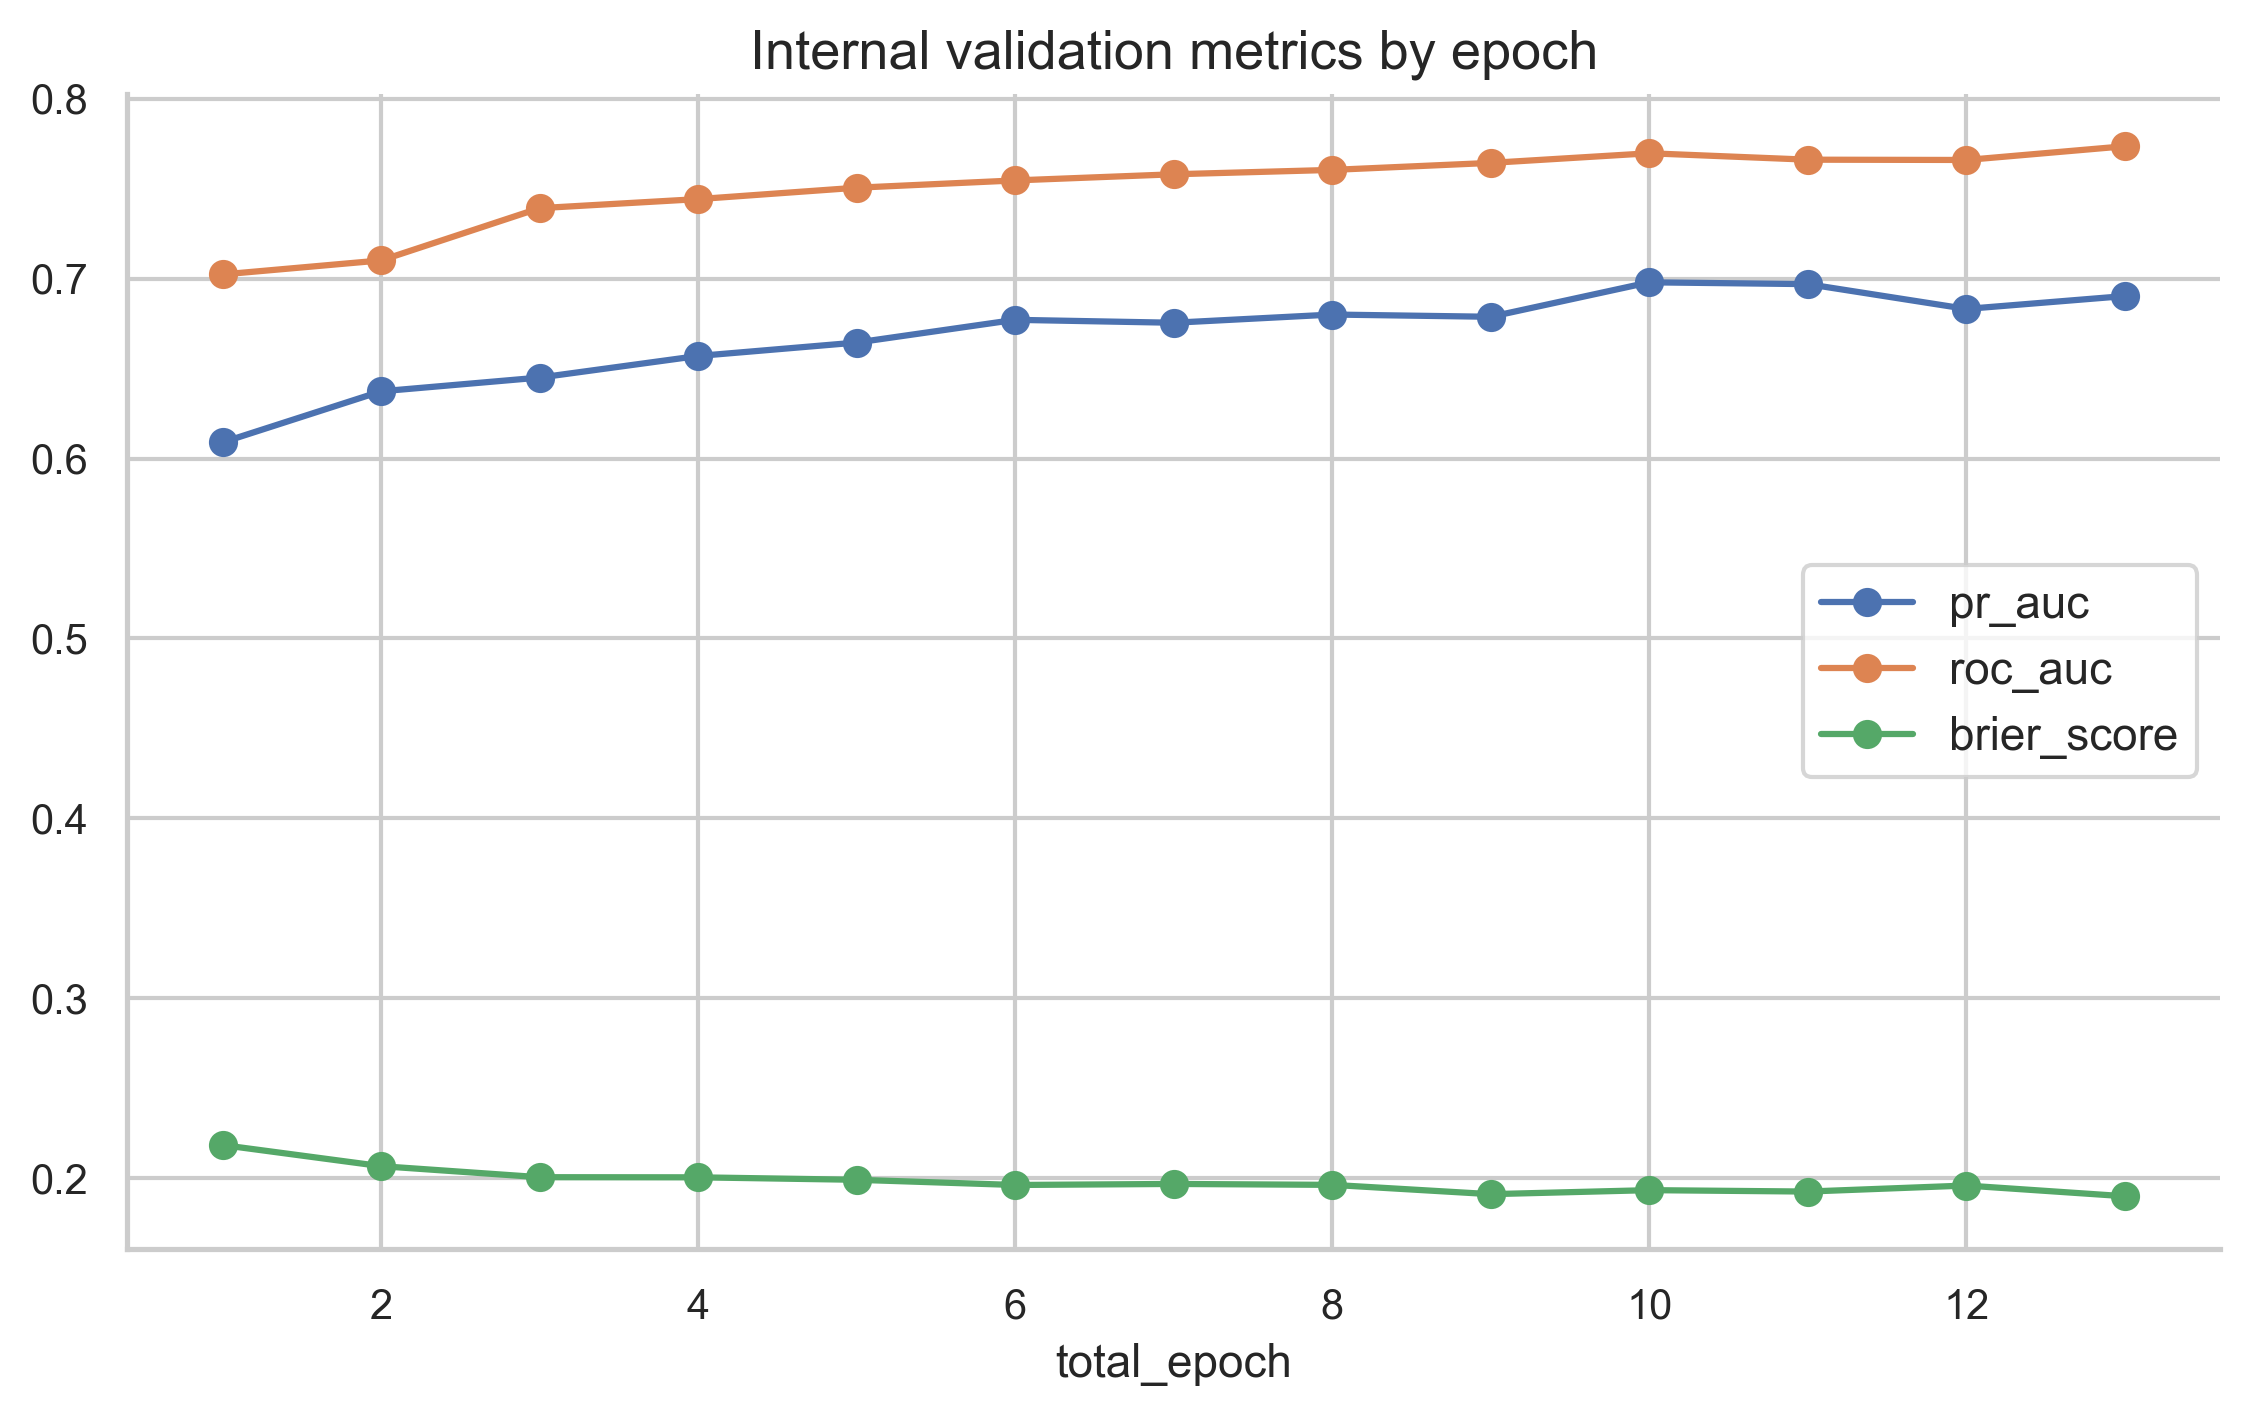

In [69]:
# Visual inspection of the internal training history.

display(internal_history)

history_plot = internal_history[
    [
        "total_epoch",
        "pr_auc",
        "roc_auc",
        "brier_score",
    ]
].set_index("total_epoch")

history_plot.plot(
    marker="o",
    figsize=(9, 5),
    title="Internal validation metrics by epoch",
)

## 10. Refit the final model on the complete training split

A **fresh EfficientNet-B0** is initialized from the same ImageNet weights and trained on all selected training lesions.

The number of warm-up and fine-tuning epochs is fixed from the internal model-development stage. The external validation set is not used for early stopping or optimizer decisions.

This is the neural-network analogue of refitting the selected XGBoost configuration on the complete training set.

In [70]:
full_train_loader = make_loader(
    dataframe=df_train_images,
    transform=train_transform,
    shuffle=True,
)

full_train_pos_weight = compute_pos_weight(
    labels=df_train_images[TARGET],
    mode=POS_WEIGHT_MODE,
)

print(f"Full-train pos_weight ({POS_WEIGHT_MODE}): {full_train_pos_weight:.3f}")


def fit_final_model(
    train_loader: DataLoader,
    pos_weight: float,
    schedule: dict,
) -> tuple[nn.Module, pd.DataFrame]:
    """Refit a fresh EfficientNet using the internally selected schedule."""

    set_seed(RANDOM_STATE)

    model = build_model(device=DEVICE)

    criterion = make_criterion(
        pos_weight=pos_weight,
        device=DEVICE,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = []
    total_epoch = 0

    # ---------------------------------------------------------
    # Warm-up
    # ---------------------------------------------------------

    warmup_epochs = int(schedule["warmup_epochs"])

    if warmup_epochs > 0:
        configure_trainable_layers(
            model=model,
            n_unfrozen_feature_blocks=0,
        )

        optimizer = make_optimizer(
            model=model,
            learning_rate=WARMUP_LR,
        )

        for stage_epoch in range(
            1,
            warmup_epochs + 1,
        ):
            total_epoch += 1

            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE,
                n_unfrozen_feature_blocks=0,
                scaler=scaler,
            )

            history.append(
                {
                    "stage": "warmup",
                    "stage_epoch": stage_epoch,
                    "total_epoch": total_epoch,
                    "train_loss": train_loss,
                }
            )

            print(f"[final warmup {stage_epoch:02d}] loss={train_loss:.5f}")

    # ---------------------------------------------------------
    # Fine-tuning
    # ---------------------------------------------------------

    fine_tune_epochs = int(schedule["fine_tune_epochs"])

    if fine_tune_epochs > 0:
        configure_trainable_layers(
            model=model,
            n_unfrozen_feature_blocks=UNFREEZE_LAST_N_BLOCKS,
        )

        optimizer = make_optimizer(
            model=model,
            learning_rate=FINE_TUNE_LR,
        )

        for stage_epoch in range(
            1,
            fine_tune_epochs + 1,
        ):
            total_epoch += 1

            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE,
                n_unfrozen_feature_blocks=UNFREEZE_LAST_N_BLOCKS,
                scaler=scaler,
            )

            history.append(
                {
                    "stage": "fine_tune",
                    "stage_epoch": stage_epoch,
                    "total_epoch": total_epoch,
                    "train_loss": train_loss,
                }
            )

            print(f"[final fine-tune {stage_epoch:02d}] loss={train_loss:.5f}")

    return model, pd.DataFrame(history)


final_model, final_training_history = fit_final_model(
    train_loader=full_train_loader,
    pos_weight=full_train_pos_weight,
    schedule=selected_schedule,
)

display(final_training_history)

Full-train pos_weight (full): 1.668
[final warmup 01] loss=0.84297
[final warmup 02] loss=0.78394
[final fine-tune 01] loss=0.78949
[final fine-tune 02] loss=0.74394
[final fine-tune 03] loss=0.71328
[final fine-tune 04] loss=0.68532
[final fine-tune 05] loss=0.66704
[final fine-tune 06] loss=0.66036
[final fine-tune 07] loss=0.64427
[final fine-tune 08] loss=0.61483


,stage,stage_epoch,total_epoch,train_loss
0,warmup,1,1,0.842969
1,warmup,2,2,0.783942
2,fine_tune,1,3,0.789487
3,fine_tune,2,4,0.743940
4,fine_tune,3,5,0.713282
5,fine_tune,4,6,0.685317
6,fine_tune,5,7,0.667038
7,fine_tune,6,8,0.660364
8,fine_tune,7,9,0.644266
9,fine_tune,8,10,0.614834


## 11. Save final model and experiment configuration

`save_model(..., model_type=2)` stores the PyTorch `state_dict` in the same model-run structure used by the common evaluation pipeline.

The run also stores:

- exact training lesion identifiers;
- exact internal train/validation assignment;
- internal model-development history;
- final refit history;
- complete experiment configuration.

In [71]:
model_directory = save_model(
    model=final_model,
    model_name=MODEL_NAME,
    model_type=2,
)


# ---------------------------------------------------------------------
# Save exact training IDs
# ---------------------------------------------------------------------

training_ids_path = Path(model_directory) / "training_lesion_ids.csv"

df_train[[ID_COLUMN]].to_csv(
    training_ids_path,
    index=False,
)


# ---------------------------------------------------------------------
# Save internal split assignment
# ---------------------------------------------------------------------

internal_split_ids = pd.concat(
    [
        df_internal_train[[ID_COLUMN, GROUP_COLUMN]].assign(internal_split="train"),
        df_internal_validation[[ID_COLUMN, GROUP_COLUMN]].assign(
            internal_split="validation"
        ),
    ],
    ignore_index=True,
)

internal_split_path = Path(model_directory) / "internal_split_lesion_ids.csv"

internal_split_ids.to_csv(
    internal_split_path,
    index=False,
)


# ---------------------------------------------------------------------
# Save training histories
# ---------------------------------------------------------------------

internal_history_path = Path(model_directory) / "internal_training_history.csv"

internal_history.to_csv(
    internal_history_path,
    index=False,
)

final_history_path = Path(model_directory) / "final_training_history.csv"

final_training_history.to_csv(
    final_history_path,
    index=False,
)


# ---------------------------------------------------------------------
# Save experiment configuration
# ---------------------------------------------------------------------


def to_python_scalar(value):
    """Convert NumPy scalar values before JSON serialization."""

    if isinstance(value, np.generic):
        return value.item()

    return value


experiment_configuration = {
    "hypothesis": HYPOTHESIS,
    "target": TARGET,
    "architecture": MODEL_ARCHITECTURE,
    "weights": str(WEIGHTS),
    "image_size": IMAGE_SIZE,
    "image_manifest": str(image_manifest_path),
    "image_timestamp_setting": IMAGE_TIMESTAMP,
    "train_full_lesions": len(df_train_full),
    "train_used_lesions": len(df_train),
    "train_max_lesions_setting": TRAIN_MAX_LESIONS,
    "train_subsample_random_state": TRAIN_SUBSAMPLE_RANDOM_STATE,
    "random_state": RANDOM_STATE,
    "internal_holdout": {
        "n_folds_used_to_define_holdout": N_INTERNAL_FOLDS,
        "selected_fold_index": INTERNAL_FOLD_INDEX,
        "train_lesions": len(df_internal_train),
        "validation_lesions": len(df_internal_validation),
        "best_metrics": {
            key: to_python_scalar(value) for key, value in internal_best_metrics.items()
        },
    },
    "class_imbalance": {
        "pos_weight_mode": POS_WEIGHT_MODE,
        "internal_pos_weight": internal_pos_weight,
        "full_train_pos_weight": full_train_pos_weight,
    },
    "training": {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "warmup_learning_rate": WARMUP_LR,
        "fine_tune_learning_rate": FINE_TUNE_LR,
        "weight_decay": WEIGHT_DECAY,
        "configured_warmup_epochs": WARMUP_EPOCHS,
        "configured_max_fine_tune_epochs": MAX_FINE_TUNE_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
        "selected_final_schedule": selected_schedule,
        "dropout": DROPOUT,
        "mixed_precision": USE_AMP,
        "device": str(DEVICE),
    },
    "augmentation": {
        "horizontal_flip_probability": 0.5,
        "vertical_flip_probability": 0.5,
        "rotation_degrees": 15,
        "brightness": 0.10,
        "contrast": 0.10,
        "saturation": 0.05,
        "imagenet_mean": list(IMAGENET_MEAN),
        "imagenet_std": list(IMAGENET_STD),
    },
}

experiment_config_path = Path(model_directory) / "training_configuration.json"

with experiment_config_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_configuration,
        file,
        indent=2,
    )


print(f"Model directory: {model_directory}")
print(f"Training IDs: {training_ids_path}")
print(f"Internal split: {internal_split_path}")
print(f"Internal history: {internal_history_path}")
print(f"Final history: {final_history_path}")
print(f"Training configuration: {experiment_config_path}")

Model saved in: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/model_state_dict.pt
Model directory: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511
Training IDs: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/training_lesion_ids.csv
Internal split: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/internal_split_lesion_ids.csv
Internal history: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/internal_training_history.csv
Final history: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/final_training_history.csv
Training configuration: /Users/carlesraichbros/my-image-classifier/data/models/efficientnet_b0_image_h2_full_train_20260829_144511/

## 12. Generate train and external-validation probabilities

Prediction uses the deterministic transform only.

The sigmoid is applied here to convert model logits into positive-class probabilities.

In [72]:
train_prediction_loader = make_loader(
    dataframe=df_train_images,
    transform=evaluation_transform,
    shuffle=False,
)

validation_prediction_loader = make_loader(
    dataframe=df_validation_images,
    transform=evaluation_transform,
    shuffle=False,
)


(
    train_y_true,
    train_probabilities,
    train_lesion_ids,
) = predict_loader(
    model=final_model,
    loader=train_prediction_loader,
    device=DEVICE,
)

(
    validation_y_true,
    validation_probabilities,
    validation_lesion_ids,
) = predict_loader(
    model=final_model,
    loader=validation_prediction_loader,
    device=DEVICE,
)


df_train_predictions = pd.DataFrame(
    {
        "isic_id": train_lesion_ids,
        "probability": train_probabilities,
    }
)

df_validation_predictions = pd.DataFrame(
    {
        "isic_id": validation_lesion_ids,
        "probability": validation_probabilities,
    }
)

display(df_train_predictions.head())
display(df_validation_predictions.head())

,isic_id,probability
0,ISIC_0077462,0.856304
1,ISIC_0079802,0.213319
2,ISIC_0082829,0.764559
3,ISIC_0085805,0.552282
4,ISIC_0096034,0.789140


,isic_id,probability
0,ISIC_0293670,0.807805
1,ISIC_0373748,0.295736
2,ISIC_0470650,0.116097
3,ISIC_0664135,0.854451
4,ISIC_0699524,0.606423


## 13. Train and validation evaluation

The common evaluation pipeline is reused unchanged.

It calculates threshold-independent metrics on train and external validation and selects the clinical threshold **exclusively from the external validation set**, using the predefined target sensitivity.

This threshold selection occurs only after model architecture, training duration and optimization decisions have been fixed.

In [73]:
results = evaluate(
    df_train_predictions=df_train_predictions,
    df_validation_predictions=df_validation_predictions,
    df_train=df_train,
    df_validation=df_validation,
    hypothesis=HYPOTHESIS,
    model_directory=model_directory,
    target_sensitivity=0.95,
)

display(results["summary"])

TRAIN AND VALIDATION EVALUATION
Model: efficientnet_b0_image_h2_full_train
Hypothesis 2: Lesion suspected to be malignant
------------------------------------------------------------------------
                                   Train      Validation
Lesions                              811             101
Patients                             504              64
Lesion prevalence                 0.3748          0.3762
------------------------------------------------------------------------
PR-AUC                            0.7955          0.6979
ROC-AUC                           0.8609          0.7723
Brier score                       0.1645          0.2093
------------------------------------------------------------------------
Selected validation threshold: 0.306977
Target sensitivity: 0.950
------------------------------------------------------------------------
Sensitivity                       0.9671          0.9737
Specificity                       0.4043          0.3016
PPV    

,metric,train,validation
0,total_lesions,811.000000,101.000000
1,total_patients,504.000000,64.000000
2,positive_lesions,304.000000,38.000000
3,negative_lesions,507.000000,63.000000
4,patients_with_positive_lesion,201.000000,22.000000
5,lesion_prevalence,0.374846,0.376238
6,patient_prevalence,0.398810,0.343750
7,pr_auc,0.795513,0.697907
8,roc_auc,0.860921,0.772348
9,brier_score,0.164468,0.209349


### Precision Recall Curve

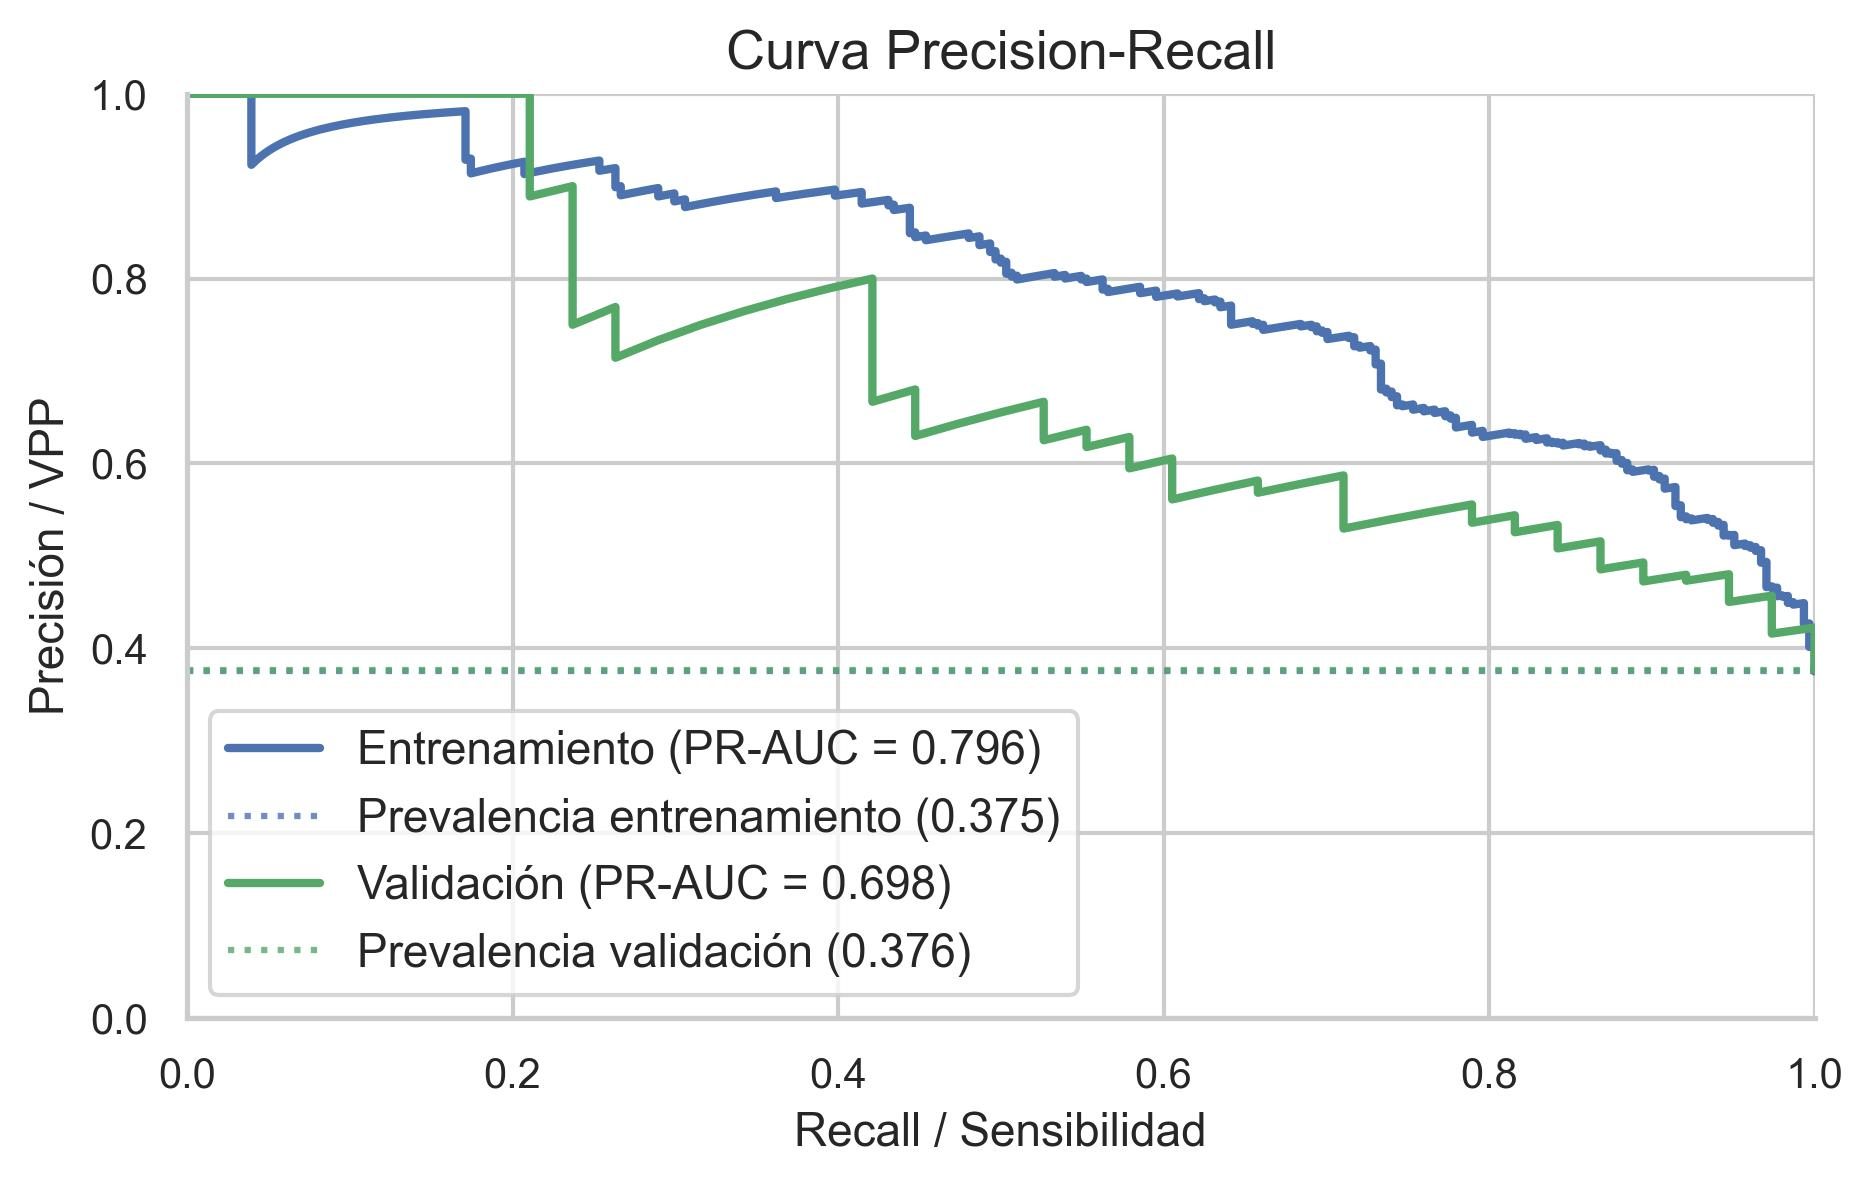

### Roc Curve

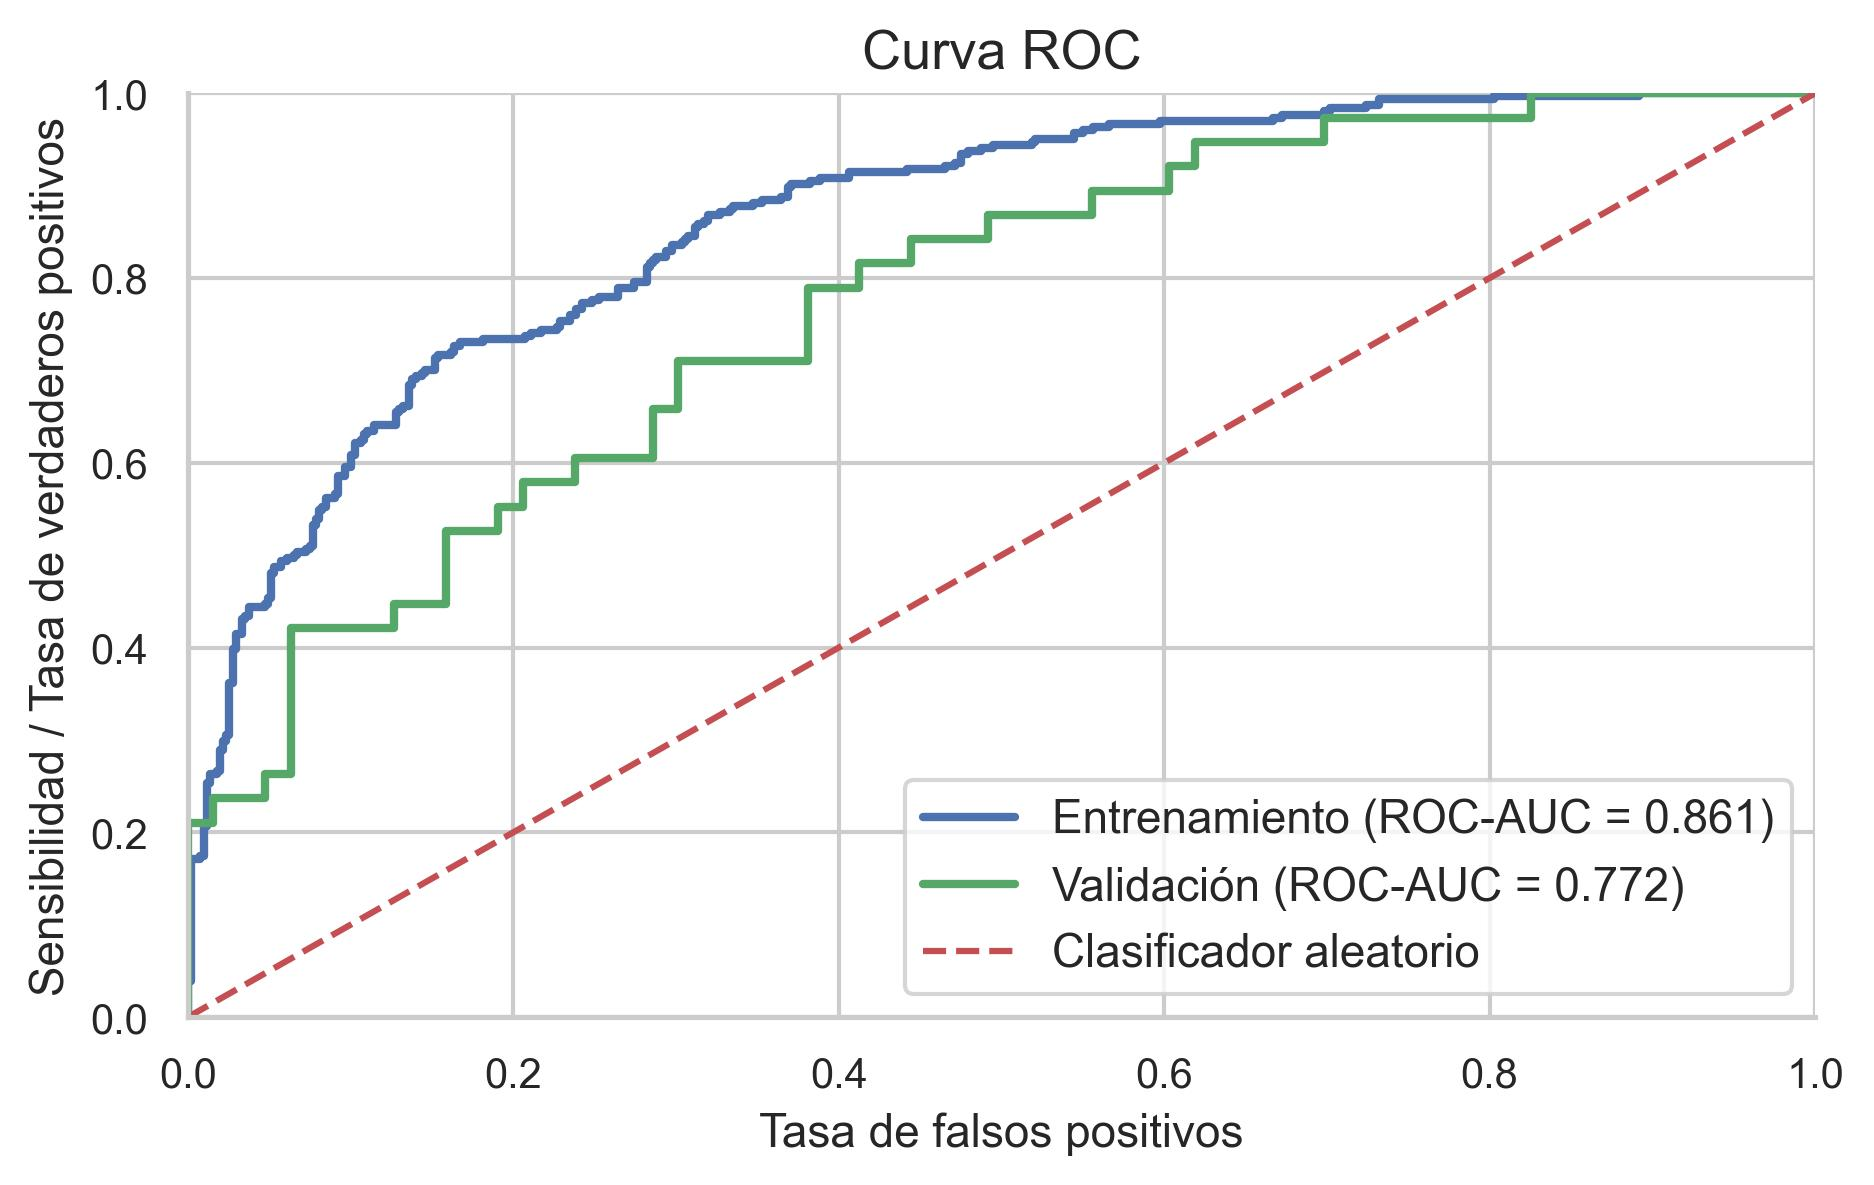

### Pr Roc Curves

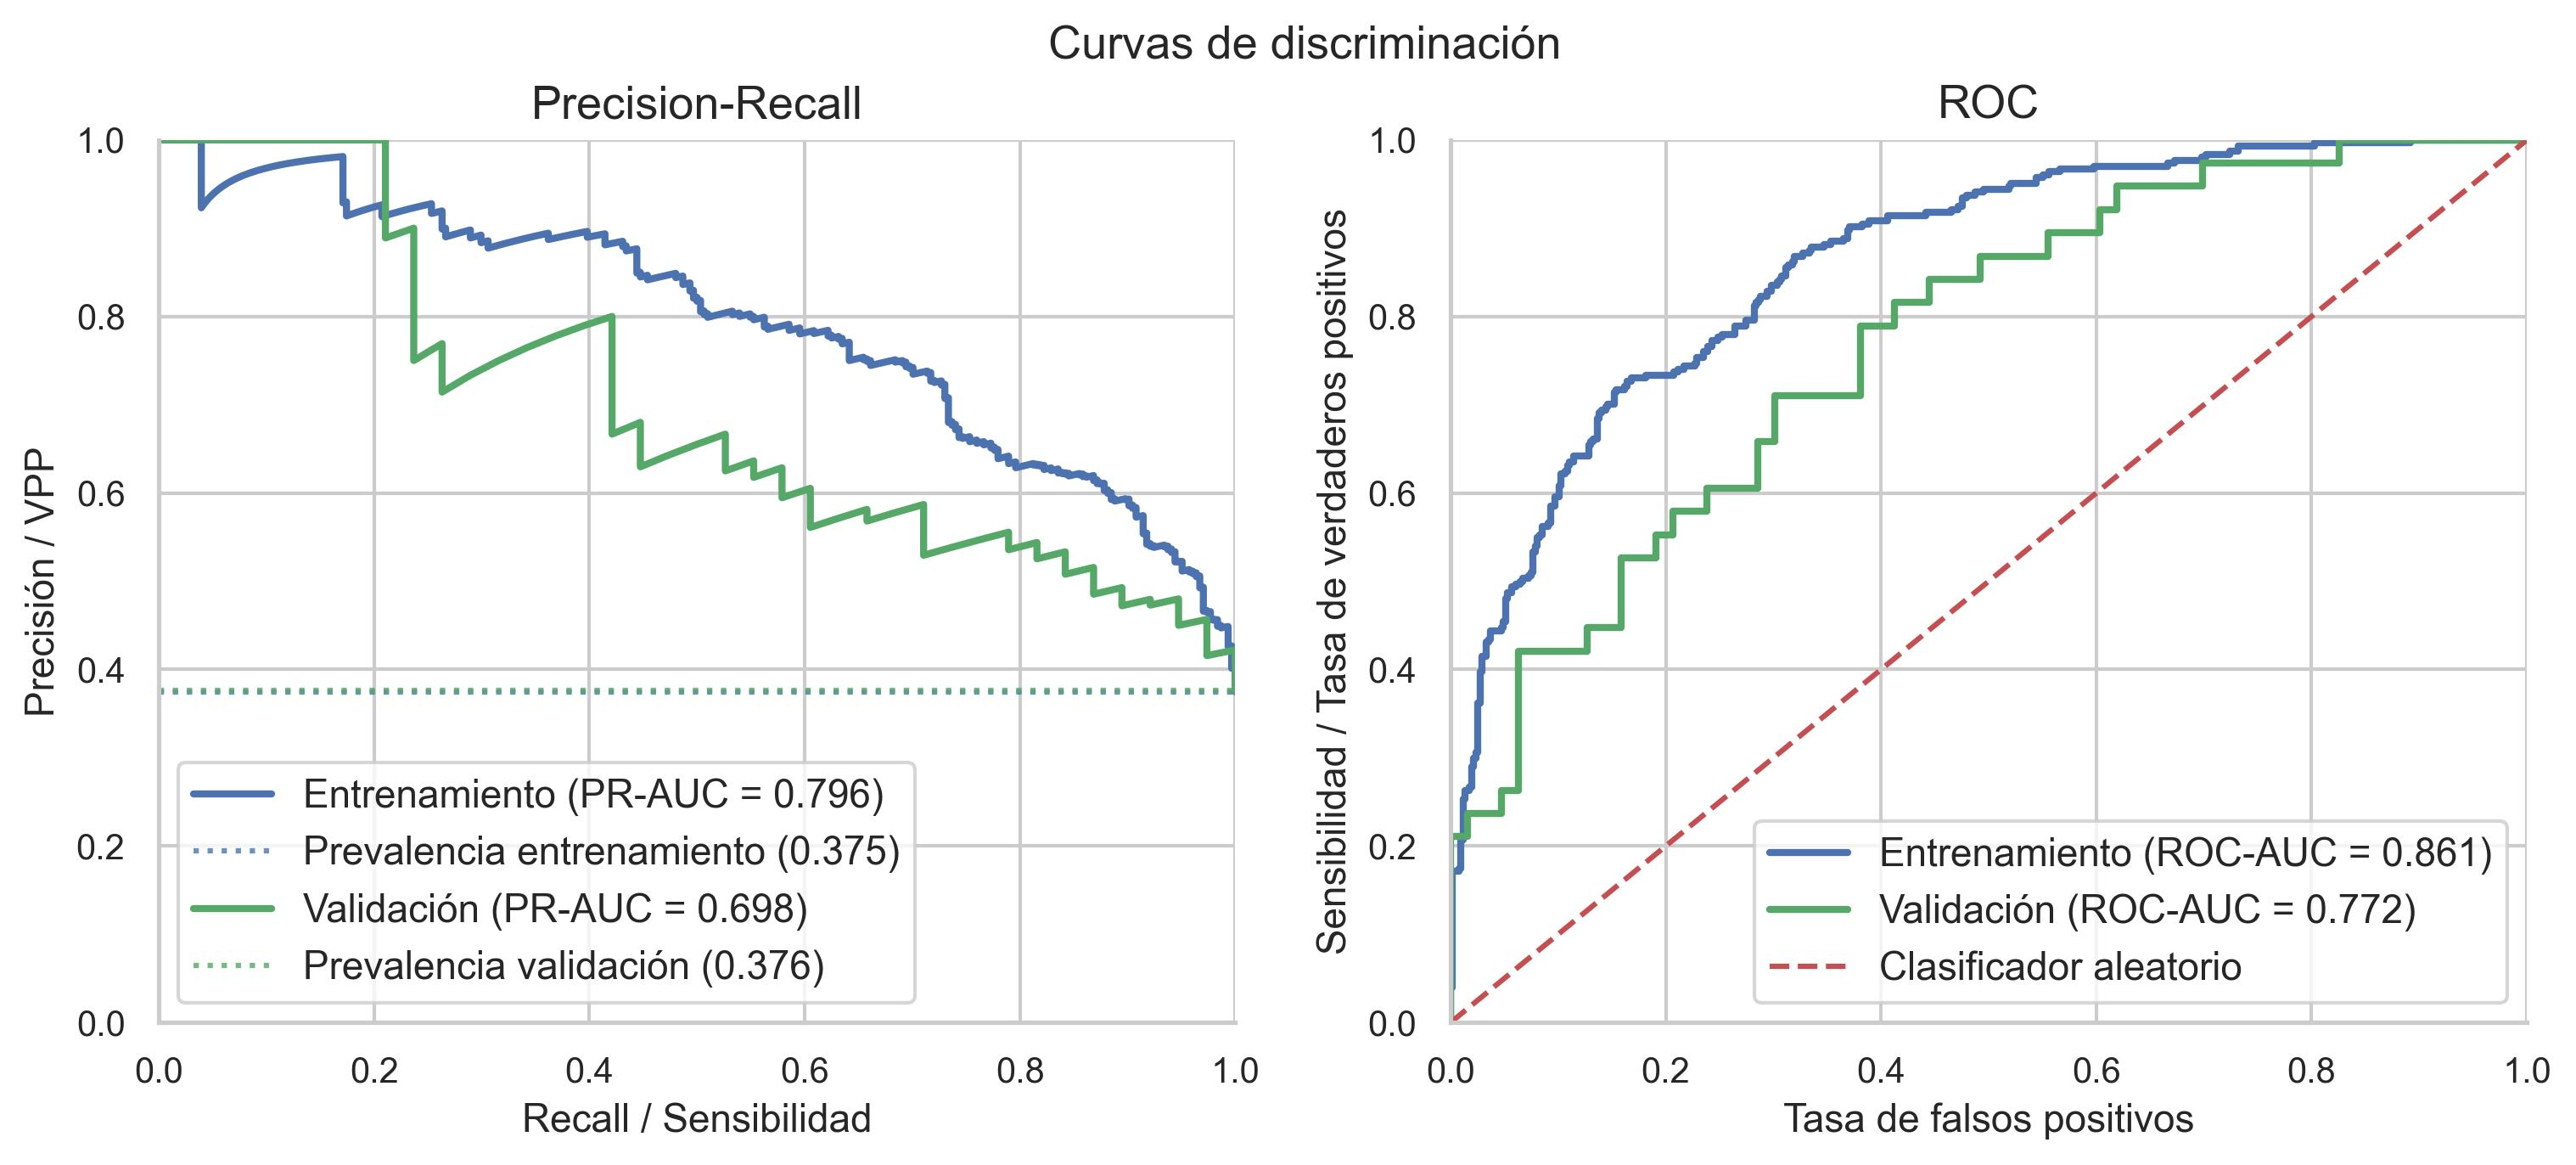

### Clinical Summary

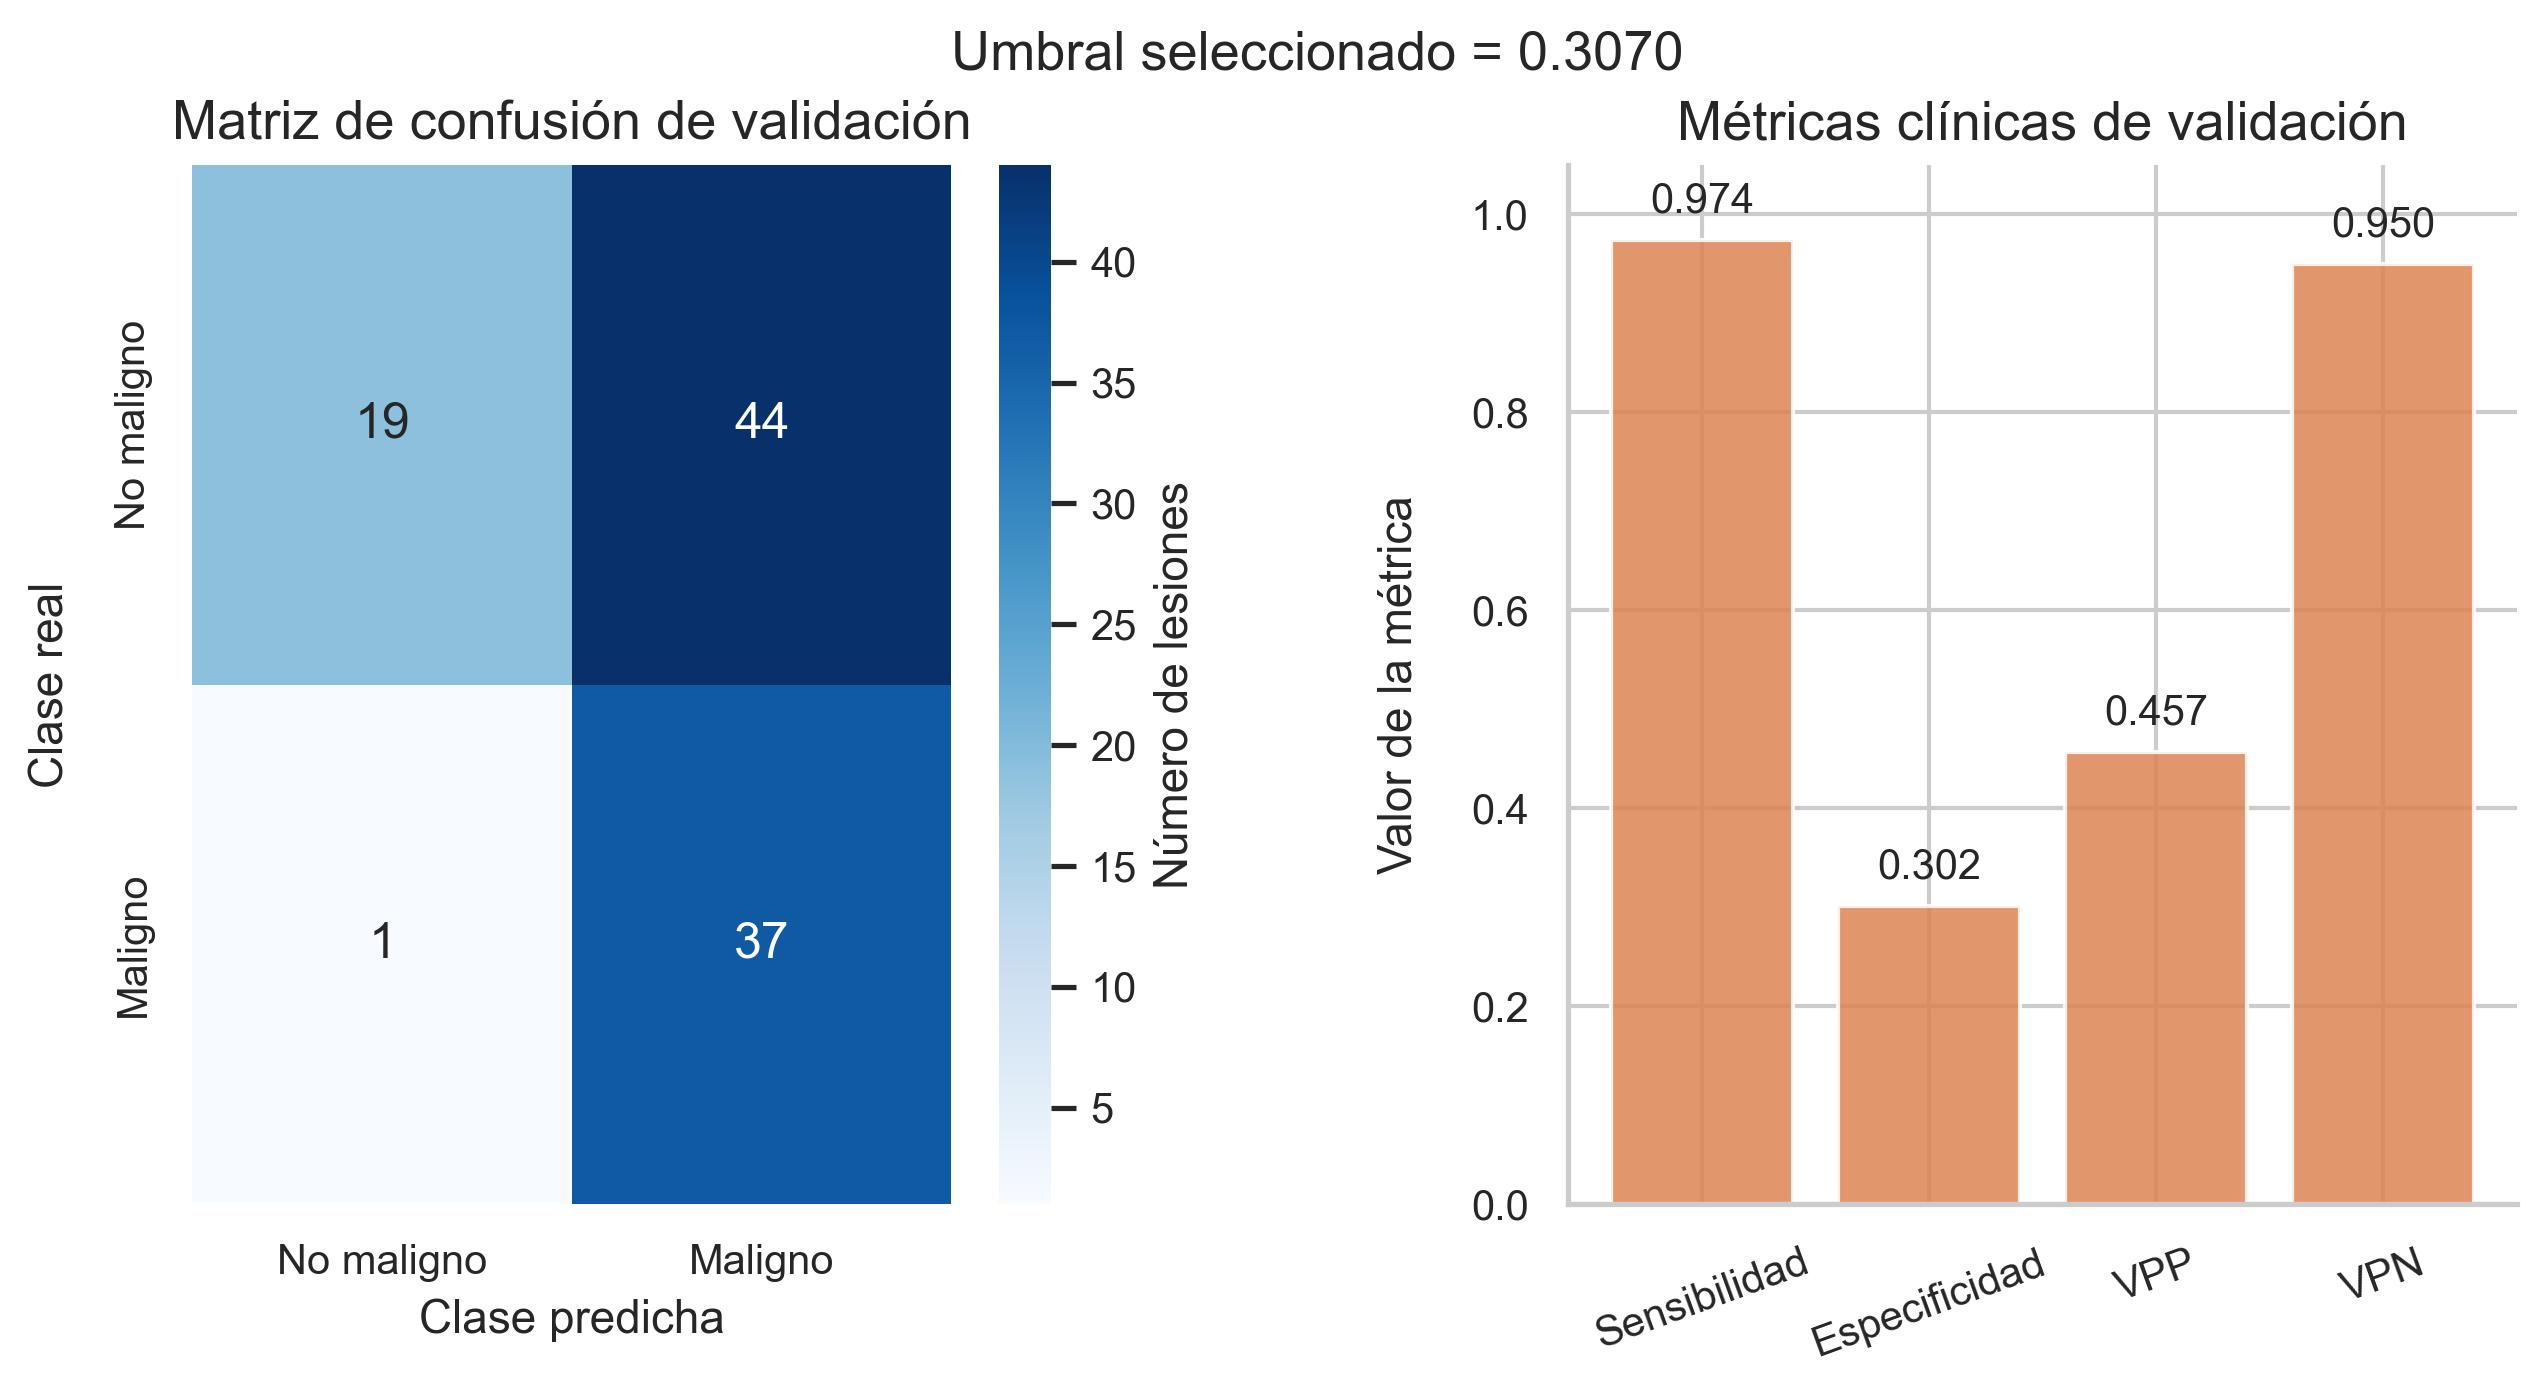

In [74]:
from IPython.display import (
    Image as IPythonImage,
    Markdown,
    display,
)

for figure_name, figure_path in results["figure_paths"].items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))

    display(IPythonImage(filename=str(figure_path)))

## Usage summary

For comparable runs, normally change only the configuration cell:

- `HYPOTHESIS = 1` or `2`.
- `TRAIN_MAX_LESIONS = None` for the full training split, or an integer for a reproducible patient-level reduced training run.
- `IMAGE_TIMESTAMP = None` to use the latest 136×136 preprocessing run, or provide an exact timestamp.
- Adjust `BATCH_SIZE` only according to available GPU memory.

Recommended first execution:

1. use a small `TRAIN_MAX_LESIONS` value as a pipeline smoke test;
2. confirm image loading, GPU training, saving and evaluation all work;
3. return to `TRAIN_MAX_LESIONS = None` for the real H1/H2 experiment.

The external test set remains untouched in this notebook. Final test evaluation should be performed only after the modelling strategy is fixed.